In [ ]:
import os

base = '/content/FF_data'
for category in os.listdir(base):
    cat_path = f'{base}/{category}'
    if os.path.isdir(cat_path):
        size = sum(os.path.getsize(os.path.join(d, f))
                   for d, _, files in os.walk(cat_path) for f in files)
        print(f"{category}: {size/1e9:.2f} GB")

DFD_fake: 4.80 GB
DFD_real: 14.63 GB
real: 3.30 GB
Face2Face: 1.27 GB
fake: 1.31 GB
NeuralTextures: 1.04 GB
FaceSwap: 1.04 GB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Unzip all files
!unzip "/content/drive/MyDrive/real.zip" -d /content/FF_data
!unzip "/content/drive/MyDrive/fake.zip" -d /content/FF_data
!unzip "/content/drive/MyDrive/FaceSwap.zip" -d /content/FF_data
!unzip "/content/drive/MyDrive/Face2Face.zip" -d /content/FF_data

!unzip "/content/drive/MyDrive/DFD_real.zip" -d /content/FF_data
!unzip "/content/drive/MyDrive/DFD_fake.zip" -d /content/FF_data
!unzip "/content/drive/MyDrive/NeuralTextures.zip" -d /content/FF_data

Streaming output truncated to the last 5000 lines.
  inflating: /content/FF_data/DFD_real/original_sequences/actors/c40/videos/15__talking_angry_couch.mp4  
  inflating: /content/FF_data/DFD_real/original_sequences/actors/c40/videos/19__outside_talking_pan_laughing.mp4  
  inflating: /content/FF_data/DFD_real/original_sequences/actors/c40/videos/14__walking_outside_cafe_disgusted.mp4  
  inflating: /content/FF_data/DFD_real/original_sequences/actors/c40/videos/27__walk_down_hall_angry.mp4  
  inflating: /content/FF_data/DFD_real/original_sequences/actors/c40/videos/05__outside_talking_pan_laughing.mp4  
  inflating: /content/FF_data/DFD_real/original_sequences/actors/c40/videos/27__kitchen_pan.mp4  
  inflating: /content/FF_data/DFD_real/original_sequences/actors/c40/videos/18__podium_speech_happy.mp4  
  inflating: /content/FF_data/DFD_real/original_sequences/actors/c40/videos/03__walk_down_hall_angry.mp4  
  inflating: /content/FF_data/DFD_real/original_sequences/actors/c40/videos/10

In [ ]:
# # Viewing timeframe jumps

# def show_jumps(grouped):
#     frame_pattern = re.compile(r'_frame_(\d+)_')

#     inconsistent = {}
#     step_counts = defaultdict(int)

#     for key, files in grouped.items():
#         frame_nums = sorted(int(frame_pattern.search(f).group(1)) for f in files)
#         steps = set(frame_nums[i+1] - frame_nums[i] for i in range(len(frame_nums) - 1))

#         if len(steps) > 1:
#             inconsistent[key] = steps
#         elif steps:
#             step_counts[next(iter(steps))] += 1

#     print("Step size distribution across all videos:")
#     for step, count in sorted(step_counts.items()):
#         print(f"  step={step}: {count} video(s)")

#     if inconsistent:
#         print(f"\nVideos with inconsistent frame steps ({len(inconsistent)}):")
#         for key, steps in inconsistent.items():
#             print(f"  {key}: {steps}")
#     else:
#         print("\nAll videos have consistent frame steps.")

Dataset information
FF_data:
DFD -> Google's deepfake dection dataset
fake and real are faceforensics data

In CSV:
0 - authentic videos
1 - deepfakes

In [ ]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from PIL import Image
from torchvision import transforms
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import torch
import torch.nn as nn
import torchvision.models as models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from pathlib import Path

Image.MAX_IMAGE_PIXELS = None
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [ ]:
# Download and process data into frames

# Download all data
# !bash FaceForensics/download_ff_data.sh

# Download 50 videos data
# !bash download_ff_data.sh --num_videos 50 --frame_skip 20

# Download one video per category
# !bash download_ff_data.sh --sample --frame_skip 20

# for high quality, add --hq at the end
# !bash download_ff_data.sh --sample --hq

In [ ]:
'''
group videos by name to get into format of map
'''

from collections import defaultdict
import re
import os
import pandas as pd

"""
Prereqs: download 10 vids/directory in all_dirs via download_ff_data.sh
"""
def group_by_video(directory):
    groups = defaultdict(list)
    for video_name in os.listdir(directory):
        video_path = os.path.join(directory, video_name)
        if not os.path.isdir(video_path):
            continue
        frames = sorted(f for f in os.listdir(video_path) if f.endswith('.png'))
        if frames:
            # change: doesn't prepend video name to frame filename
            groups[video_name] = [f for f in frames]

    result = []
    for key, frames in groups.items():
        result.append([key, frames])
    return result


def extract_original_vid(path: str):
    # use this to ensure that original videos and their manipulated derivatives
    # are all in the same side of the split, so that the model is only evaluated on data
    # it hasn't seen before

    name = Path(path).name

    # matches DFD fakes, first number is the og, then name should match
    m = re.fullmatch(r'(\d+)_\d+__(.+)__([A-Z0-9]{8})', name)
    if m:
        return f"{m.group(1)}__{m.group(2)}"

    # DFD reals
    m = re.fullmatch(r'(\d+)__(.+)', name)
    if m:
        return f"{m.group(1)}__{m.group(2)}"

    # rest of the fakes, first number is the target
    m = re.fullmatch(r'(\d+)_(\d+)', name)
    if m:
        return m.group(1)

    # FF reals
    if re.fullmatch(r'\d+', name):
        return name

    return None

In [ ]:
from numpy.random.mtrand import f
'''
create csv storing:
Video_name, frame 1, frame 2, .. frame 10
'''

all_dirs = ['/content/FF_data/real/original_sequences/youtube/c40/images',
            '/content/FF_data/fake/manipulated_sequences/Deepfakes/c40/images',
            '/content/FF_data/DFD_real/original_sequences/actors/c40/images',
            '/content/FF_data/DFD_fake/manipulated_sequences/DeepFakeDetection/c40/images',
            '/content/FF_data/Face2Face/manipulated_sequences/Face2Face/c40/images',
            '/content/FF_data/FaceSwap/manipulated_sequences/FaceSwap/c40/images',
            '/content/FF_data/NeuralTextures/manipulated_sequences/NeuralTextures/c40/images',
            ]

# Check each directory has 50 videos
print("=== Directory Video Count Check ===")
for d in all_dirs:
    d_videos = d.replace('images', 'videos')
    if not os.path.exists(d_videos):
        print(f"MISSING DIR: {d_videos}")
        continue
    videos = [v for v in os.listdir(d_videos) if v.endswith(('.mp4', '.avi', '.mov', '.mkv'))]
    if len(videos) != 50:
        print(f"WRONG COUNT ({len(videos)}/50): {d_videos}")
print("=== Check Complete ===")

'''
0 - Authentic
1 - Deepfake
'''

def create_datamap(all_dirs, frames_per_clip=10, skip=1):
    data = {
        'video_path': [],
        "video_name": []
    }
    for i in range(10):
        data['frame_' + str(i)] = []

    data['label'] = []

    for dir in all_dirs:
        label = 1
        if 'original' in dir:
            label = 0
        # list of videos in dir, along with a list of frame filenames with them
        #[[vid, [vid/fr1.png, vid/fr2.png, ...]], ...]
        video_map = group_by_video(dir)
        for video, frames in video_map:
            i = 0
            for j in range(frames_per_clip * skip, len(frames), frames_per_clip * skip):
                if skip == 1:
                    split = frames[i:j]
                else:
                    split = [frames[idx] for idx in range(i, j, skip)]
                i = j
                data['video_path'].append(os.path.join(dir, video))
                data["video_name"].append(video)
                data['label'].append(label)
                for k in range(len(split)):
                    data['frame_' + str(k)].append(split[k])
    return data

data_map = create_datamap(all_dirs)
df = pd.DataFrame(data_map)
df['original_vid'] = df['video_name'].apply(extract_original_vid)
print(f"Total clips = {len(df)}")
vidnames = list(set(df["original_vid"]))
print(f"Total videos = {len(vidnames)}")
# df.to_csv('whole_dataset_splits.csv') # for testing dataset


=== Directory Video Count Check ===
WRONG COUNT (200/50): /content/FF_data/real/original_sequences/youtube/c40/videos
WRONG COUNT (80/50): /content/FF_data/fake/manipulated_sequences/Deepfakes/c40/videos
WRONG COUNT (200/50): /content/FF_data/DFD_real/original_sequences/actors/c40/videos
WRONG COUNT (80/50): /content/FF_data/DFD_fake/manipulated_sequences/DeepFakeDetection/c40/videos
WRONG COUNT (65/50): /content/FF_data/Face2Face/manipulated_sequences/Face2Face/c40/videos
WRONG COUNT (80/50): /content/FF_data/FaceSwap/manipulated_sequences/FaceSwap/c40/videos
WRONG COUNT (80/50): /content/FF_data/NeuralTextures/manipulated_sequences/NeuralTextures/c40/videos
=== Check Complete ===
Total clips = 2005
Total videos = 425


In [ ]:
from torchvision import transforms
from sklearn.model_selection import train_test_split

class FrameDataset(Dataset):
    def __init__(self, df, res=500, transform=None):
        self.df = df
        self.transform = transform or transforms.ToTensor()
        self.res = res

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        """
        Returns a clip tensor of shape (3, T, H, W) = (3, 10, res, res).
        The DataLoader will stack these into (B, 3, T, H, W).
        """
        vidpath = self.df["video_path"].iloc[idx]
        tensors = []
        for i in range(10):
            fname = self.df[f"frame_{i}"].iloc[idx]
            path = os.path.join(vidpath, fname)
            img = Image.open(path).convert('RGB').resize((self.res, self.res))
            tensors.append(self.transform(img))  # (3, res, res)
        clip = torch.stack(tensors, dim=1)  # (3, T, res, res)
        label = int(self.df["label"].iloc[idx])
        return clip, label


train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# split by original video so fakes and their source stay on the same side
vid_labels     = df.groupby('original_vid')['label'].first()
vid_label_list = [vid_labels[v] for v in vidnames]

# train_vids, test_vids = train_test_split(vidnames, test_size=0.2, random_state=108)

# train_df = df[df['original_vid'].isin(set(train_vids))].reset_index(drop=True)
# test_df  = df[df['original_vid'].isin(set(test_vids))].reset_index(drop=True)

test_df = pd.read_csv("test_dataset_splits.csv")
train_df = pd.read_csv("train_dataset_splits.csv")

# print("Writting Train CSV")
# train_df.to_csv('train_dataset_splits.csv')

# print("Writting Test CSV")
# test_df.to_csv('test_dataset_splits.csv')

train_dataset = FrameDataset(train_df, res=224, transform=train_transform)
test_dataset  = FrameDataset(test_df,  res=224, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")
for frames, label in train_loader:
    print(frames.shape)
    print(label)
    break

Train samples: 1579, Test samples: 426
torch.Size([32, 3, 10, 224, 224])
tensor([1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
        1, 0, 0, 1, 1, 0, 0, 0])


In [ ]:
# Model

model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

print(f'Model:      ResNet-50 (from scratch)')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Device:     {device}')

Model:      ResNet-50 (from scratch)
Parameters: 23,512,130
Device:     cuda


In [ ]:
# Training
from sklearn.utils.class_weight import compute_class_weight

# weight classes to account for imbalance
train_labels = train_dataset.df['label'].values
weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = torch.FloatTensor(weights).to(device)

criterion  = nn.CrossEntropyLoss(weight=class_weights)
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3)
NUM_EPOCHS = 20

# checkpoint_path = '/content/checkpoints/checkpoint_epoch_20.pt'  # set this to your checkpoint path

start_epoch = 0
train_losses = []
train_accs   = []

# if os.path.exists(checkpoint_path):
#     checkpoint = torch.load(checkpoint_path, map_location=device)
#     model.load_state_dict(checkpoint['model_state_dict'])
#     optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
#     start_epoch = checkpoint['epoch'] + 1
#     print(f'Resumed from checkpoint: {checkpoint_path} (epoch {checkpoint["epoch"]})')
#     train_losses = [.8343, .7110, .7108, .7128, .6927, .6570, .6336, .6461, .6447, .6232]
#     train_accs = [.7806, .8409, .7869, .8389, .8540, .8618, .8235, .8429, .8570, .8343]
# else:
#     print('No checkpoint found, training from scratch.')

for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    for clips, labels in train_loader:
        # clips: (B, 3, T, H, W) — flatten T into batch dimension
        clips, labels = clips.to(device), labels.to(device)
        B, C, T, H, W = clips.shape

        optimizer.zero_grad()

        frames = clips.permute(0, 2, 1, 3, 4).reshape(B * T, C, H, W)  # (B*T, 3, H, W)
        frame_outputs = model(frames)                                     # (B*T, 2)
        outputs = frame_outputs.reshape(B, T, -1).mean(dim=1)            # (B, 2) averaged logits per clip

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds    = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc  = correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    print(f'Epoch {epoch+1:02d}/{NUM_EPOCHS} | '
          f'Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}')
    if epoch % 10 == 0:
      print("saved checkpoint", epoch)
      torch.save({
          'epoch': epoch,
          'model_state_dict': model.state_dict(),
          'optimizer_state_dict': optimizer.state_dict(),
          'loss': loss,
      }, f'/content/checkpoints/checkpoint_epoch_{epoch}.pt')

print('\nTraining Done')

Epoch 01/20 | Loss: 0.7789 | Acc: 0.5852
saved checkpoint 0
Epoch 02/20 | Loss: 0.6933 | Acc: 0.5966
Epoch 03/20 | Loss: 0.6563 | Acc: 0.6783
Epoch 04/20 | Loss: 0.6169 | Acc: 0.7023
Epoch 05/20 | Loss: 0.6553 | Acc: 0.6479
Epoch 06/20 | Loss: 0.5971 | Acc: 0.6922
Epoch 07/20 | Loss: 0.5930 | Acc: 0.7093
Epoch 08/20 | Loss: 0.5629 | Acc: 0.7213
Epoch 09/20 | Loss: 0.5506 | Acc: 0.7296
Epoch 10/20 | Loss: 0.5266 | Acc: 0.7619
Epoch 11/20 | Loss: 0.5401 | Acc: 0.7410
saved checkpoint 10
Epoch 12/20 | Loss: 0.5106 | Acc: 0.7568
Epoch 13/20 | Loss: 0.4901 | Acc: 0.7904
Epoch 14/20 | Loss: 0.4782 | Acc: 0.7815
Epoch 15/20 | Loss: 0.4818 | Acc: 0.7840
Epoch 16/20 | Loss: 0.4631 | Acc: 0.7815
Epoch 17/20 | Loss: 0.4484 | Acc: 0.7986
Epoch 18/20 | Loss: 0.4600 | Acc: 0.7872
Epoch 19/20 | Loss: 0.4334 | Acc: 0.8018
Epoch 20/20 | Loss: 0.4314 | Acc: 0.8011

Training Done


In [ ]:
# saving training results
save_path = '/content/resnet50_baseline_scratch (3).pth'
# torch.save(model.state_dict(), save_path)
print(f'Model saved to {save_path}')

Model saved to /content/resnet50_baseline_scratch (3).pth


In [ ]:
# Evaluation

model = models.resnet50(pretrained=False) # Change to resnet50
model.fc = nn.Linear(model.fc.in_features, 2)

model.load_state_dict(torch.load(save_path, map_location=device))
model = model.to(device)
model.eval()
print('Model loaded.')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded.


In [ ]:
# Evaluation Metrics
y_true, y_pred = [], []
misclassified_fakes = []  # store filenames of fake videos misclassified as real

with torch.no_grad():
    for batch_idx, (clips, labels) in enumerate(test_loader):
        clips = clips.to(device)
        B, C, T, H, W = clips.shape

        frames = clips.permute(0, 2, 1, 3, 4).reshape(B * T, C, H, W)
        frame_outputs = model(frames)
        outputs = frame_outputs.reshape(B, T, -1).mean(dim=1)

        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        y_true.extend(labels.numpy())
        y_pred.extend(preds)

        # Check for fake (1) predicted as real (0)
        for i in range(B):
            if labels[i].item() == 1 and preds[i] == 0:
                global_idx = batch_idx * test_loader.batch_size + i
                filepath = test_loader.dataset.df["video_path"].iloc[global_idx]
                misclassified_fakes.append(filepath)

print('=== BASELINE RESULTS (Clip-Level Averaged Logits) ===\n')
print(classification_report(
    y_true, y_pred,
    labels=[0, 1],
    target_names=['Real (0)', 'Fake (1)'],
    zero_division=0
))
print('Confusion Matrix:')
print(confusion_matrix(y_true, y_pred, labels=[0, 1]))
print(f'\nF1 (weighted): {f1_score(y_true, y_pred, average="weighted", zero_division=0):.4f}')
print(f'F1 (macro):    {f1_score(y_true, y_pred, average="macro", zero_division=0):.4f}')

# Write misclassified fakes to file
output_path = '/content/misclassified_fakes.txt'
with open(output_path, 'w') as f:
    f.write(f"Fake videos misclassified as Real ({len(misclassified_fakes)} total):\n\n")
    for filepath in misclassified_fakes:
        f.write(filepath + '\n')

print(f'\nMisclassified fakes written to {output_path} ({len(misclassified_fakes)} videos)')

=== BASELINE RESULTS (Clip-Level Averaged Logits) ===

              precision    recall  f1-score   support

    Real (0)       0.56      0.49      0.52       246
    Fake (1)       0.40      0.46      0.43       180

    accuracy                           0.48       426
   macro avg       0.48      0.48      0.47       426
weighted avg       0.49      0.48      0.48       426

Confusion Matrix:
[[121 125]
 [ 97  83]]

F1 (weighted): 0.4820
F1 (macro):    0.4747

Misclassified fakes written to /content/misclassified_fakes.txt (97 videos)


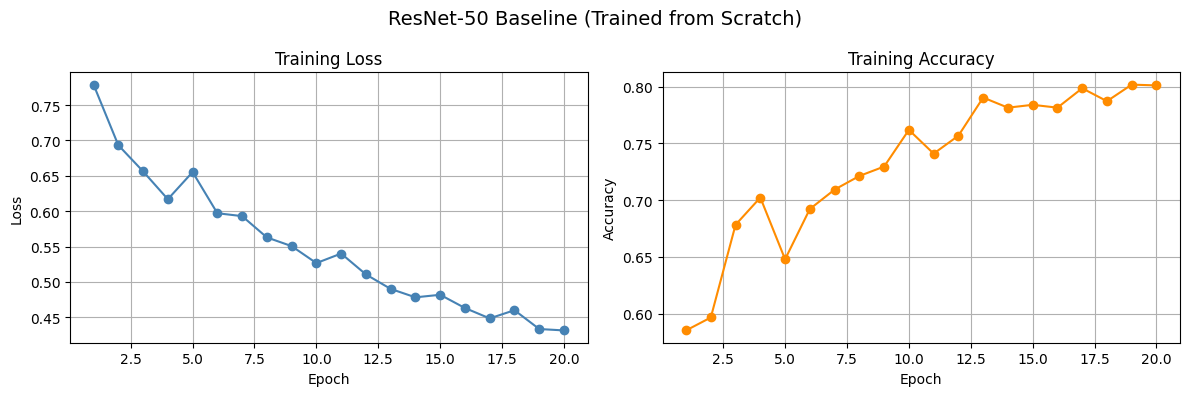

Saved


In [ ]:
# Evalution plots

# if training skipped
train_losses = [0.7789, 0.6933, 0.6563, 0.6169, 0.6553, 0.5971, 0.5930, 0.5629, 0.5506, 0.5266, 0.5401, 0.5106, 0.4901, 0.4782, 0.4818, 0.4631, 0.4484, 0.4600, 0.4334, 0.4314]

train_accs = [0.5852, 0.5966, 0.6783, 0.7023, 0.6479, 0.6922, 0.7093, 0.7213, 0.7296, 0.7619, 0.7410, 0.7568, 0.7904, 0.7815, 0.7840, 0.7815, 0.7986, 0.7872, 0.8018, 0.8011]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, 20+1), train_losses, marker='o', color='steelblue')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(range(1, 20+1), train_accs, marker='o', color='darkorange')
ax2.set_title('Training Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.grid(True)

plt.suptitle('ResNet-50 Baseline (Trained from Scratch)', fontsize=14)
plt.tight_layout()
plt.savefig('/content/baseline_training_curves.png')
plt.show()
print('Saved')